In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data/processed/preprocessed_dataset_fadly.csv')

In [3]:
#distribusi label
print('\n Distribusi label')
print(df['label'].value_counts())
print(f'\n Presentase')
print(df['label'].value_counts(normalize=True))


 Distribusi label
label
0.0    26279
1.0     5927
2.0     1479
Name: count, dtype: int64

 Presentase
label
0.0    0.780140
1.0    0.175954
2.0    0.043907
Name: proportion, dtype: float64


In [4]:
df

,clean_text,label,char_len,word_count
0,nyata bestienya koruptor kakap pertamina riva ...,0.0,244,38
1,salah satu lebih pertamax oplos rubah suara kn...,2.0,70,10
2,juga win,1.0,12,3
3,td pagi buka tiktok yang lucu sekarang konoha ...,0.0,130,22
4,herman khaeron amplop pertamina oplos,0.0,43,6
...,...,...,...,...
33680,update klaseman liga korupsi indonesia pt pert...,0.0,250,37
33681,tidak takut korupsi skr bukan m lg rtsan t mkn...,0.0,189,36
33682,info pente klaseman liga korupsi indonesia lki,0.0,56,8
33683,klaseman korupsi edar revisi arti kasus posisi...,0.0,85,12


In [5]:
df2=df
df2['label'] = df['label'].map(
    {0:'negatif',1:'netral',2:'positif'}
)

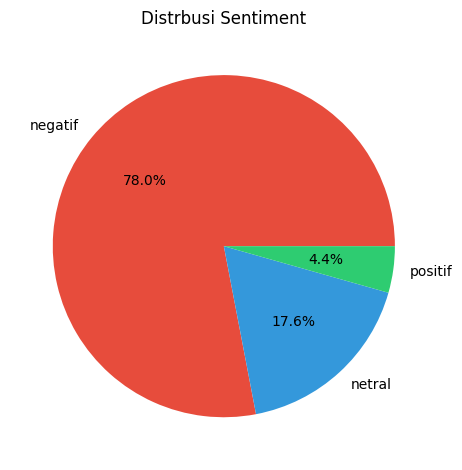

In [6]:
#fig,axes = plt.subplots(1,2,figsize=(14,5))

#Pie Charts distribusi label
colors = {
    'positif': '#2ecc71',
    'negatif': '#e74c3c',
    'netral': '#3498db'
}

label_counts = df2['label'].value_counts()
plt.pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%',
            colors=[colors[label] for label in label_counts.index])
plt.title('Distrbusi Sentiment')

plt.tight_layout()
plt.savefig('distribusi_label.png', dpi=300)
plt.show()

In [7]:
#panjang text per sentimen
df_only_text_clean = df2
df_only_text_clean['text_length'] = df_only_text_clean['clean_text'].apply(len)
df_only_text_clean.groupby('label')['text_length'].mean()

label
negatif    98.009818
netral     61.800405
positif    83.678161
Name: text_length, dtype: float64

In [8]:
from wordcloud import WordCloud

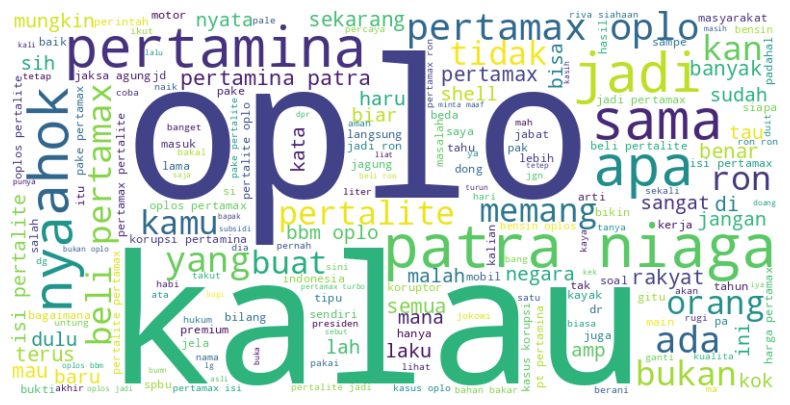

In [9]:
text = ' '.join(df_only_text_clean['clean_text'].astype(str))

#buat wordcloud

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [10]:
from matplotlib import colormaps

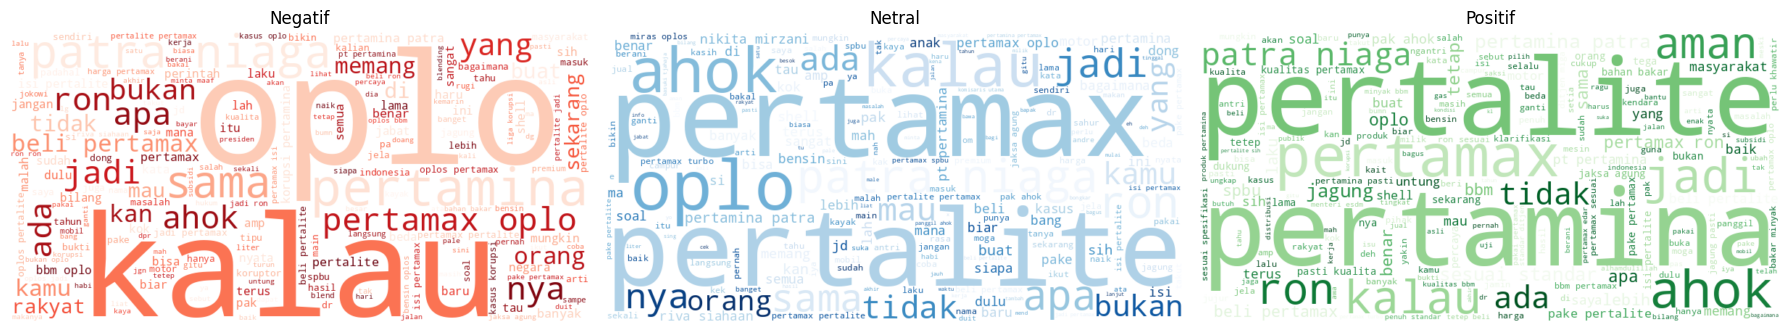

In [11]:
#sentimen negatif (label = 0)
text_negatif = ' '.join(df_only_text_clean[df_only_text_clean['label']=='negatif']['clean_text'].astype(str))
wc_negatif = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap = 'Reds'
).generate(text_negatif)

text_netral = ' '.join(df_only_text_clean[df_only_text_clean['label']=='netral']['clean_text'].astype(str))
wc_netral = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap = 'Blues'
).generate(text_netral)

text_positif = ' '.join(df_only_text_clean[df_only_text_clean['label']=='positif']['clean_text'].astype(str))
wc_positif = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap = 'Greens'
).generate(text_positif)


fig, axes = plt.subplots(1,3, figsize=(18,5))

axes[0].imshow(wc_negatif, interpolation='bilinear')
axes[0].set_title('Negatif')
axes[0].axis('off')

axes[1].imshow(wc_netral, interpolation='bilinear')
axes[1].set_title('Netral')
axes[1].axis('off')

axes[2].imshow(wc_positif, interpolation='bilinear')
axes[2].set_title('Positif')
axes[2].axis('off')

plt.tight_layout()
plt.show()